In [1]:
from sklearn.datasets import make_classification
import numpy as np
X, y = make_classification(n_samples=100, n_features=2, n_informative=1, n_redundant=0, n_classes=2, n_clusters_per_class=1, random_state=41, hypercube=False, class_sep=10)

In [2]:
import matplotlib.pyplot as plt

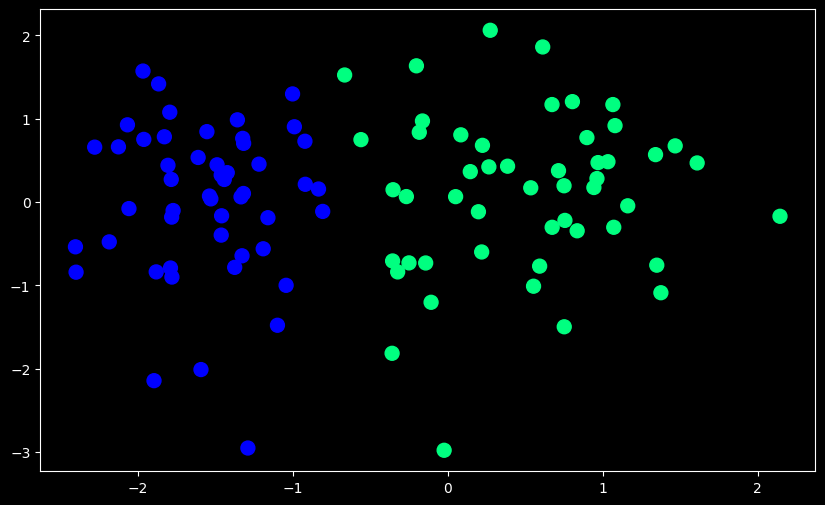

In [3]:
plt.figure(figsize=(10, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='winter', s=100)

In [35]:
def perceptron(X, y):
    X = np.insert(X, 0, 1, axis=1)
    n_samples, n_features = X.shape
    weights = np.zeros(n_features)
    # print(weights.shape)
    lr = 0.01
    epochs = 1000

    def step(z):
        return 1 if z > 0 else 0

    for i in range(epochs):
        idx = np.random.randint(0, n_samples)
        y_pred = step(weights.dot(X[idx]))
        error = y[idx] - y_pred
        weights += (lr * error * X[idx])

    return weights[0], weights[1:]


In [36]:
intercept_, coef_ = perceptron(X, y)

In [37]:
intercept_, coef_

(np.float64(0.01), array([0.01382731, 0.00047009]))

In [38]:
m = -(coef_[0]/coef_[1])
b = -(intercept_/coef_[1])

In [39]:
m, b

(np.float64(-29.414404657657563), np.float64(-21.272684189978385))

In [40]:
x_input = np.linspace(-3, 3, 100)
y_input = m*x_input + b

(-3.0, 2.0)

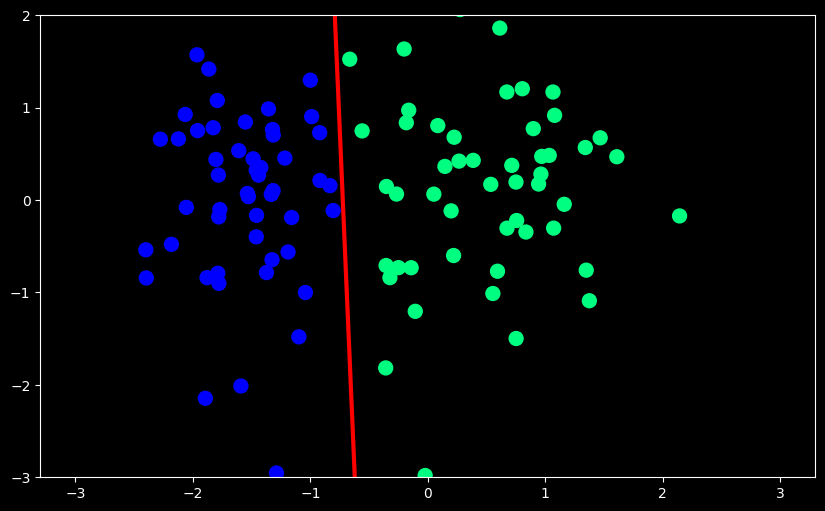

In [41]:
plt.figure(figsize=(10, 6))
plt.plot(x_input, y_input, color = 'red', linewidth = 3)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='winter', s=100)
plt.ylim(-3,2)

In [42]:
from sklearn.linear_model import LogisticRegression
lor = LogisticRegression()
lor.fit(X,y)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [43]:
m = -(lor.coef_[0][0]/lor.coef_[0][1])
b = -(lor.intercept_/lor.coef_[0][1])

In [44]:
x_input1 = np.linspace(-3,3,100)
y_input1 = m*x_input + b

(-3.0, 2.0)

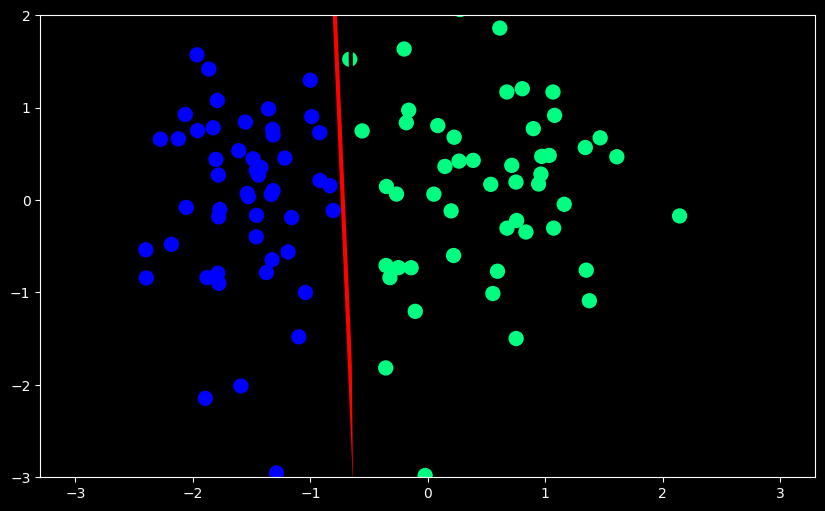

In [45]:
plt.figure(figsize=(10,6))
plt.plot(x_input,y_input,color='red',linewidth=3)
plt.plot(x_input1,y_input1,color='black',linewidth=3)
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.ylim(-3,2)